1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

2. Load the Dataset

In [4]:
# Load the raw sales dataset
df = pd.read_csv("../data/sales_data.csv")

# Display the first five rows
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,1-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,1-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,1-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,1-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,1-Jun-14,6,June,2014


3. Initial Dataset Inspection

In [5]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (700, 16)

Column Names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

Data Types:
Segment                 object
Country                 object
Product                 object
Discount Band           object
Units Sold             float64
Manufacturing Price      int64
Sale Price               int64
Gross Sales            float64
Discounts              float64
 Sales                 float64
COGS                   float64
Profit                 float64
Date                    object
Month Number             int64
Month Name              object
Year                     int64
dtype: object


4. Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        647 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9    Sales               700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

5. Statistical Summary

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Segment,700,5,Government,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,700,5,Germany,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,700,6,Paseo,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discount Band,647,3,High,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units Sold,700.0,NaN,NaN,NaN,1608.294286,867.427859,200.0,905.0,1542.5,2229.125,4492.5
Manufacturing Price,700.0,NaN,NaN,NaN,96.477143,108.602612,3.0,5.0,10.0,250.0,260.0
Sale Price,700.0,NaN,NaN,NaN,118.428571,136.775515,7.0,12.0,20.0,300.0,350.0
Gross Sales,700.0,NaN,NaN,NaN,182759.426429,254262.284378,1799.0,17391.75,37980.0,279025.0,1207500.0
Discounts,700.0,NaN,NaN,NaN,13150.354629,22962.928775,0.0,800.32,2585.25,15956.34375,149677.5
Sales,700.0,NaN,NaN,NaN,169609.0718,236726.34691,1655.08,15928.0,35540.2,261077.5,1159200.0


6. Missing Value Analysis

In [8]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing Values:")
print(missing_values)

Missing Values:
Discount Band    53
dtype: int64


7. Duplicate Record Analysis

In [9]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


8. Unique Values Analysis

In [10]:
for column in df.columns:
    print(f"\n{column}: {df[column].nunique()} unique values")


Segment: 5 unique values

Country: 5 unique values

Product: 6 unique values

Discount Band: 3 unique values

Units Sold: 510 unique values

Manufacturing Price: 6 unique values

Sale Price: 7 unique values

Gross Sales: 550 unique values

Discounts: 515 unique values

 Sales: 559 unique values

COGS: 545 unique values

Profit: 557 unique values

Date: 16 unique values

Month Number: 12 unique values

Month Name: 12 unique values

Year: 2 unique values


9. Data Cleaning

In [11]:
# Create a copy of the original dataset
df_cleaned = df.copy()

# Remove leading and trailing spaces from column names
df_cleaned.columns = df_cleaned.columns.str.strip()

# Remove leading and trailing spaces from text columns
text_columns = df_cleaned.select_dtypes(include="object").columns

for column in text_columns:
    df_cleaned[column] = df_cleaned[column].str.strip()

# Convert Date column to datetime format
df_cleaned["Date"] = pd.to_datetime(
    df_cleaned["Date"],
    format="%d-%b-%y"
)

# Check the cleaned column names
print("Cleaned Column Names:")
print(df_cleaned.columns.tolist())

# Check Date data type
print("\nDate Data Type:")
print(df_cleaned["Date"].dtype)

Cleaned Column Names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

Date Data Type:
datetime64[ns]


10. Handling Missing Values

In [12]:
# Check missing values before handling them
print("Missing values before handling:")
print(df_cleaned.isnull().sum())

Missing values before handling:
Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64


In [13]:
# Fill missing Discount Band values
df_cleaned["Discount Band"] = df_cleaned["Discount Band"].fillna("Unknown")

# Check missing values after handling
print("Missing values after handling:")
print(df_cleaned.isnull().sum())

Missing values after handling:
Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64


11. Duplicate Check After Cleaning

In [14]:
# Check for duplicate rows
duplicate_count = df_cleaned.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


12. Final Data Quality Check

In [15]:
print("Final Dataset Shape:", df_cleaned.shape)

print("\nTotal Missing Values:", df_cleaned.isnull().sum().sum())

print("Total Duplicate Rows:", df_cleaned.duplicated().sum())

Final Dataset Shape: (700, 16)

Total Missing Values: 0
Total Duplicate Rows: 0


13. Save Cleaned Dataset

In [16]:
# Save the cleaned dataset
output_path = "../data/sales_data_cleaned.csv"

df_cleaned.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_path)

Cleaned dataset saved successfully!
File: ../data/sales_data_cleaned.csv


14. Verify Cleaned Dataset

In [17]:
# Load the saved cleaned dataset to verify it
df_check = pd.read_csv(output_path)

print("Cleaned Dataset Shape:", df_check.shape)

print("\nColumns:")
print(df_check.columns.tolist())

print("\nMissing Values:")
print(df_check.isnull().sum())

print("\nDuplicate Rows:", df_check.duplicated().sum())

df_check.head()

Cleaned Dataset Shape: (700, 16)

Columns:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

Missing Values:
Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

Duplicate Rows: 0


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,Unknown,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,Unknown,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,Unknown,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,Unknown,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,Unknown,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


15. Exploratory Data Analysis (EDA)

In [18]:
# 1 Load Cleaned Dataset
# Use the cleaned dataset for EDA
df = pd.read_csv("../data/sales_data_cleaned.csv")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Display the first five rows
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,Unknown,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,Unknown,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,Unknown,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,Unknown,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,Unknown,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [19]:
# 2 Sales Summary
# Calculate basic sales metrics
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
minimum_sales = df["Sales"].min()
maximum_sales = df["Sales"].max()

print("Total Sales:", total_sales)
print("Average Sales:", average_sales)
print("Minimum Sales:", minimum_sales)
print("Maximum Sales:", maximum_sales)

Total Sales: 118726350.25999999
Average Sales: 169609.07179999998
Minimum Sales: 1655.08
Maximum Sales: 1159200.0


In [20]:
# 3 Profit Summary
# Calculate basic profit metrics
total_profit = df["Profit"].sum()
average_profit = df["Profit"].mean()
minimum_profit = df["Profit"].min()
maximum_profit = df["Profit"].max()

print("Total Profit:", total_profit)
print("Average Profit:", average_profit)
print("Minimum Profit:", minimum_profit)
print("Maximum Profit:", maximum_profit)

Total Profit: 16893702.26
Average Profit: 24133.860371428575
Minimum Profit: -40617.5
Maximum Profit: 262200.0


In [21]:
# 4 Sales by Country
sales_by_country = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_country

Country
United States of America    2.502983e+07
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
Name: Sales, dtype: float64

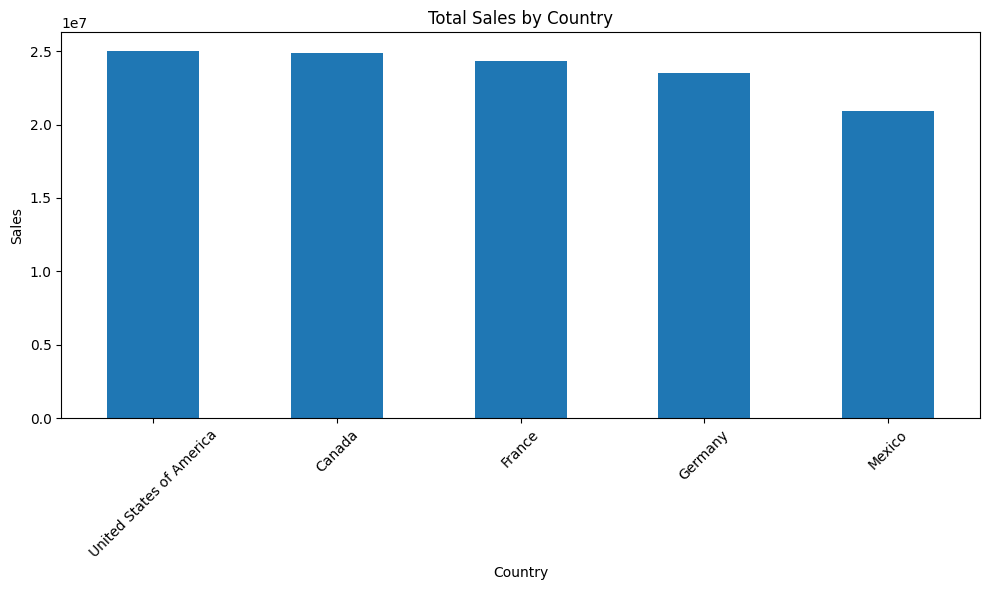

In [22]:
# 5 Sales by Country Visualization
plt.figure(figsize=(10, 6))

sales_by_country.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# 6 Sales by Product
sales_by_product = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_product

Product
Paseo        3.301114e+07
VTT          2.051192e+07
Velo         1.825006e+07
Amarilla     1.774712e+07
Montana      1.539080e+07
Carretera    1.381531e+07
Name: Sales, dtype: float64

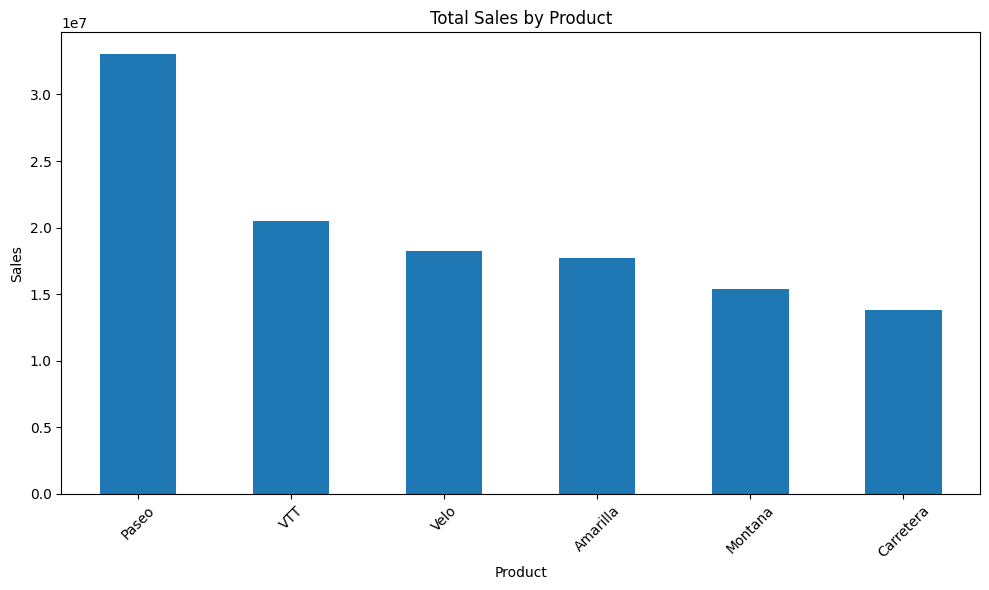

In [24]:
# 7 Sales by Product Visualization
plt.figure(figsize=(10, 6))

sales_by_product.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# 8 Sales by Segment
sales_by_segment = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

Segment
Government          5.250426e+07
Small Business      4.242792e+07
Enterprise          1.961169e+07
Midmarket           2.381883e+06
Channel Partners    1.800594e+06
Name: Sales, dtype: float64

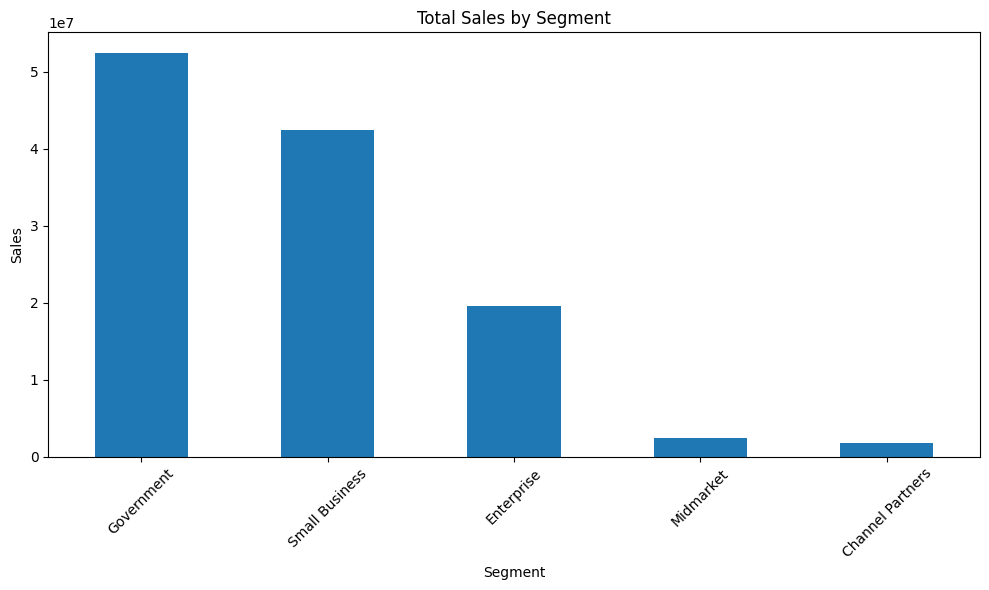

In [26]:
# 9 Sales by Segment Visualization
plt.figure(figsize=(10, 6))

sales_by_segment.plot(kind="bar")

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

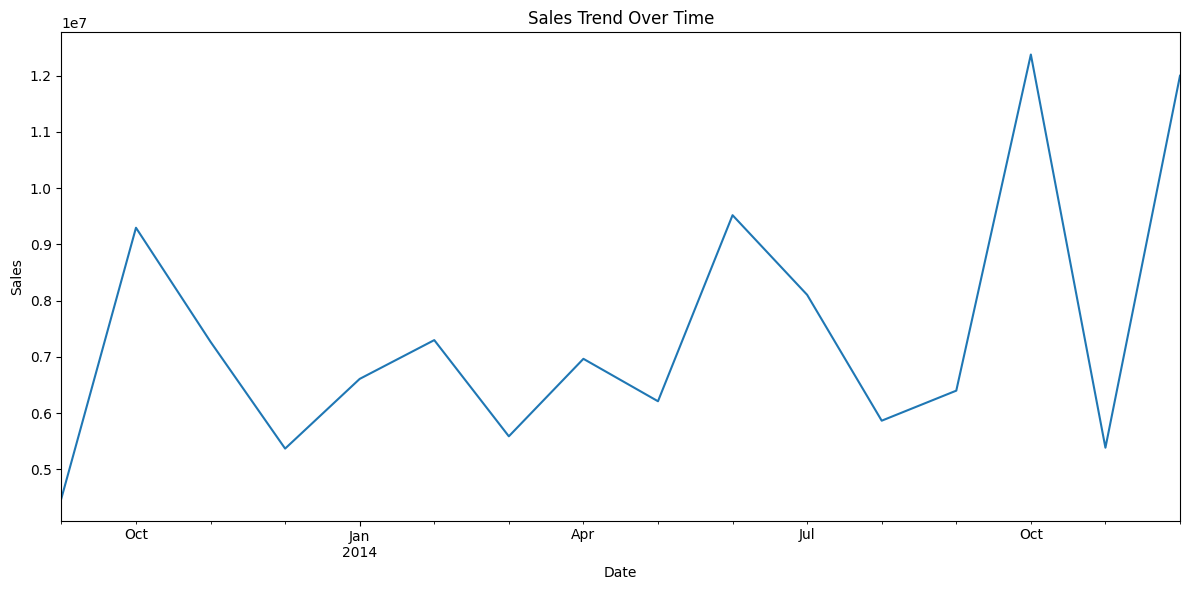

In [27]:
# 10 Sales Trend Over Time
sales_by_date = (
    df.groupby("Date")["Sales"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sales_by_date.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

16. Profit Analysis

In [28]:
# Calculate total profit by country
profit_by_country = (
    df.groupby("Country")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_country

Country
France                      3781020.780
Germany                     3680388.820
Canada                      3529228.885
United States of America    2995540.665
Mexico                      2907523.110
Name: Profit, dtype: float64

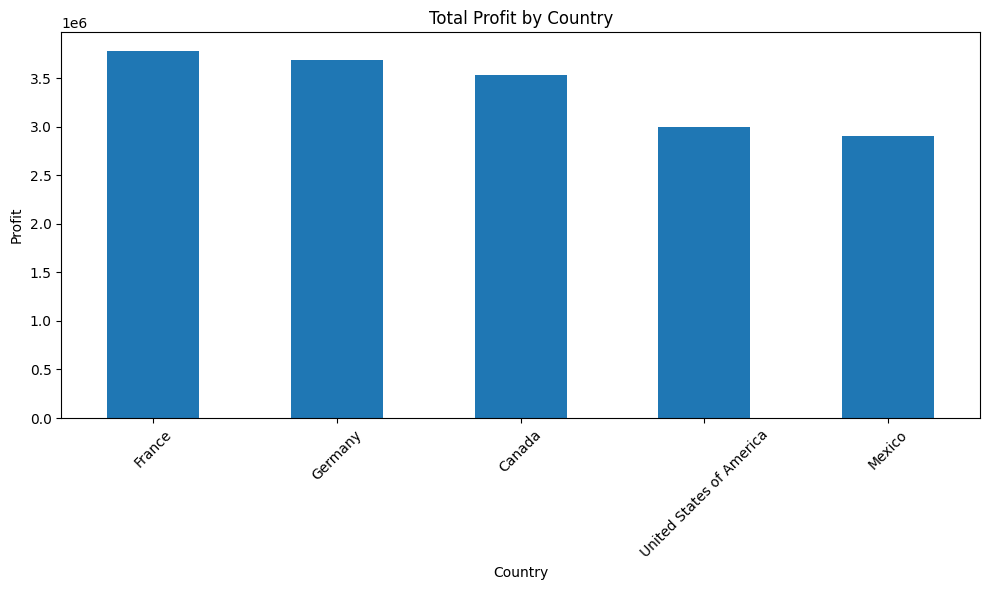

In [29]:
# 1 Profit by Country Visualization

plt.figure(figsize=(10, 6))

profit_by_country.plot(kind="bar")

plt.title("Total Profit by Country")
plt.xlabel("Country")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# 2 Profit by Product
profit_by_product = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_product

Product
Paseo        4797437.950
VTT          3034608.020
Amarilla     2814104.060
Velo         2305992.465
Montana      2114754.880
Carretera    1826804.885
Name: Profit, dtype: float64

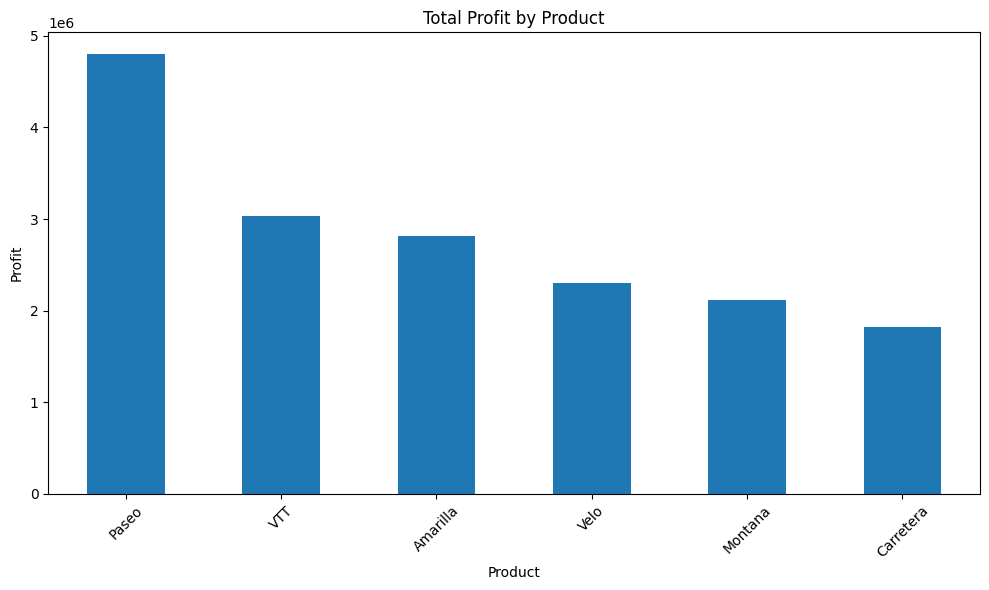

In [31]:
# 3 Profit by Product Visualization
plt.figure(figsize=(10, 6))

profit_by_product.plot(kind="bar")

plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# 4 Profit by Segment
profit_by_segment = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_segment

Segment
Government          1.138817e+07
Small Business      4.143168e+06
Channel Partners    1.316803e+06
Midmarket           6.601031e+05
Enterprise         -6.145456e+05
Name: Profit, dtype: float64

17. Units Sold Analysis

In [33]:
units_by_product = (
    df.groupby("Product")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

units_by_product

Product
Paseo        338239.5
VTT          168783.0
Velo         162424.5
Amarilla     155315.0
Montana      154198.0
Carretera    146846.0
Name: Units Sold, dtype: float64

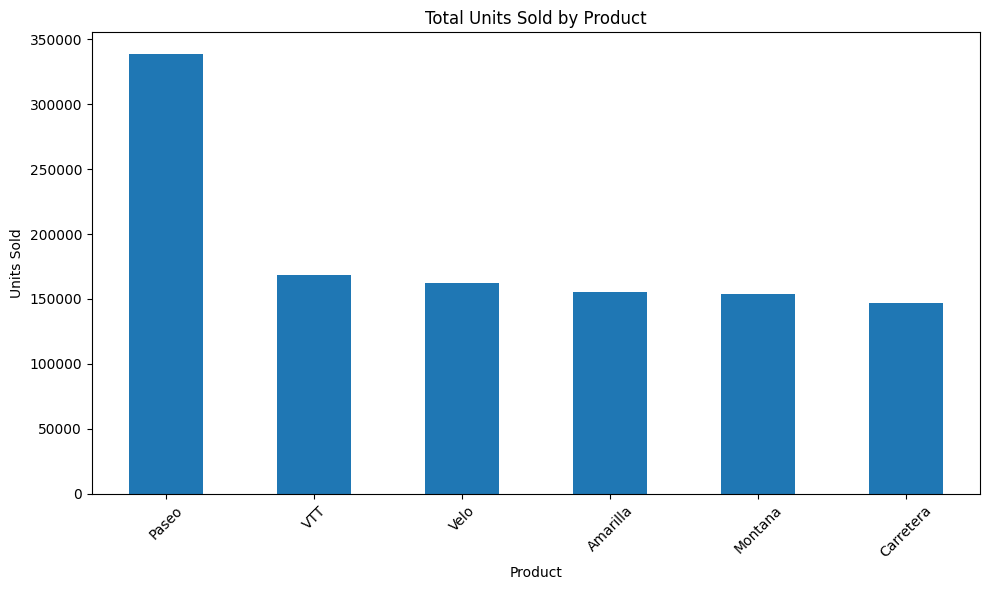

In [34]:
# 1 Units Sold by Product Visualization
plt.figure(figsize=(10, 6))

units_by_product.plot(kind="bar")

plt.title("Total Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

18. Discount Analysis

In [35]:
discount_analysis = (
    df.groupby("Discount Band")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Discounts=("Discounts", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

discount_analysis

,Total_Sales,Total_Discounts,Total_Profit
Discount Band,,,
Medium,3.878043e+07,3002546.165,5579522.835
High,3.737249e+07,5317026.275,3388866.725
Low,3.462978e+07,885675.800,6188857.700
Unknown,7.943654e+06,0.000,1736455.000


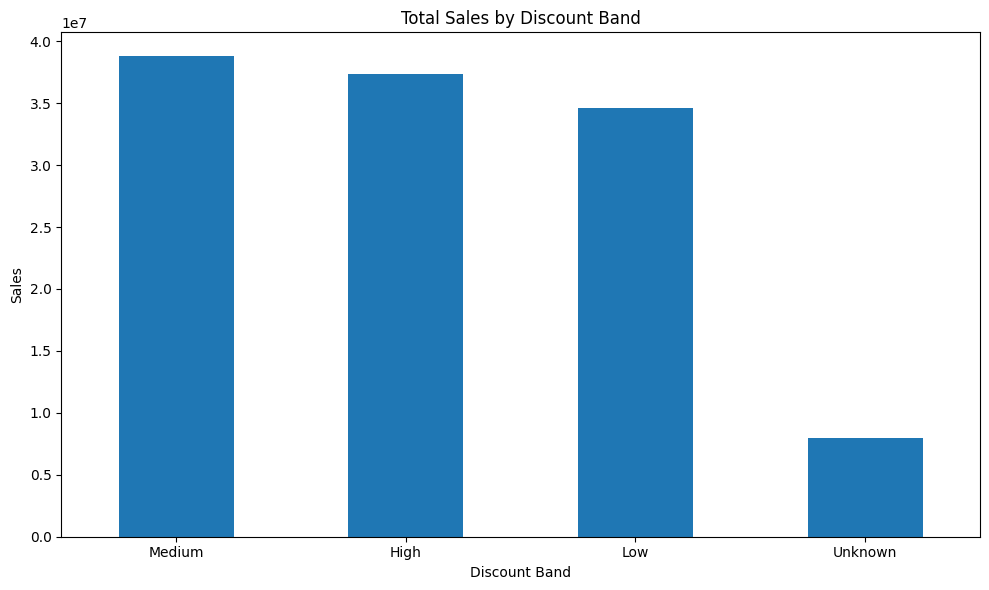

In [36]:
# 1 Sales by Discount Band
plt.figure(figsize=(10, 6))

discount_analysis["Total_Sales"].plot(kind="bar")

plt.title("Total Sales by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

19. Correlation Analysis

In [37]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numeric_columns.corr()

correlation_matrix

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
Units Sold,1.000000,-0.029644,-6.506581e-02,0.327221,0.253048,0.326914,0.331694,0.228437,-1.036069e-01,6.385658e-02
Manufacturing Price,-0.029644,1.000000,7.078637e-02,0.049852,0.020578,0.051549,0.046857,0.061985,5.021388e-03,-9.271955e-04
Sale Price,-0.065066,0.070786,1.000000e+00,0.808250,0.641689,0.805878,0.799335,0.650495,1.742840e-16,1.829362e-13
Gross Sales,0.327221,0.049852,8.082502e-01,1.000000,0.782485,0.998174,0.994519,0.784508,-3.496563e-02,4.443489e-02
Discounts,0.253048,0.020578,6.416890e-01,0.782485,1.000000,0.743447,0.782930,0.383087,-5.359162e-02,2.239741e-02
Sales,0.326914,0.051549,8.058777e-01,0.998174,0.743447,1.000000,0.992244,0.805462,-3.235728e-02,4.555389e-02
COGS,0.331694,0.046857,7.993354e-01,0.994519,0.782930,0.992244,1.000000,0.725544,-3.615842e-02,4.731019e-02
Profit,0.228437,0.061985,6.504947e-01,0.784508,0.383087,0.805462,0.725544,1.000000,-6.743698e-03,2.663408e-02
Month Number,-0.103607,0.005021,1.742840e-16,-0.034966,-0.053592,-0.032357,-0.036158,-0.006744,1.000000e+00,-4.276786e-01
Year,0.063857,-0.000927,1.829362e-13,0.044435,0.022397,0.045554,0.047310,0.026634,-4.276786e-01,1.000000e+00


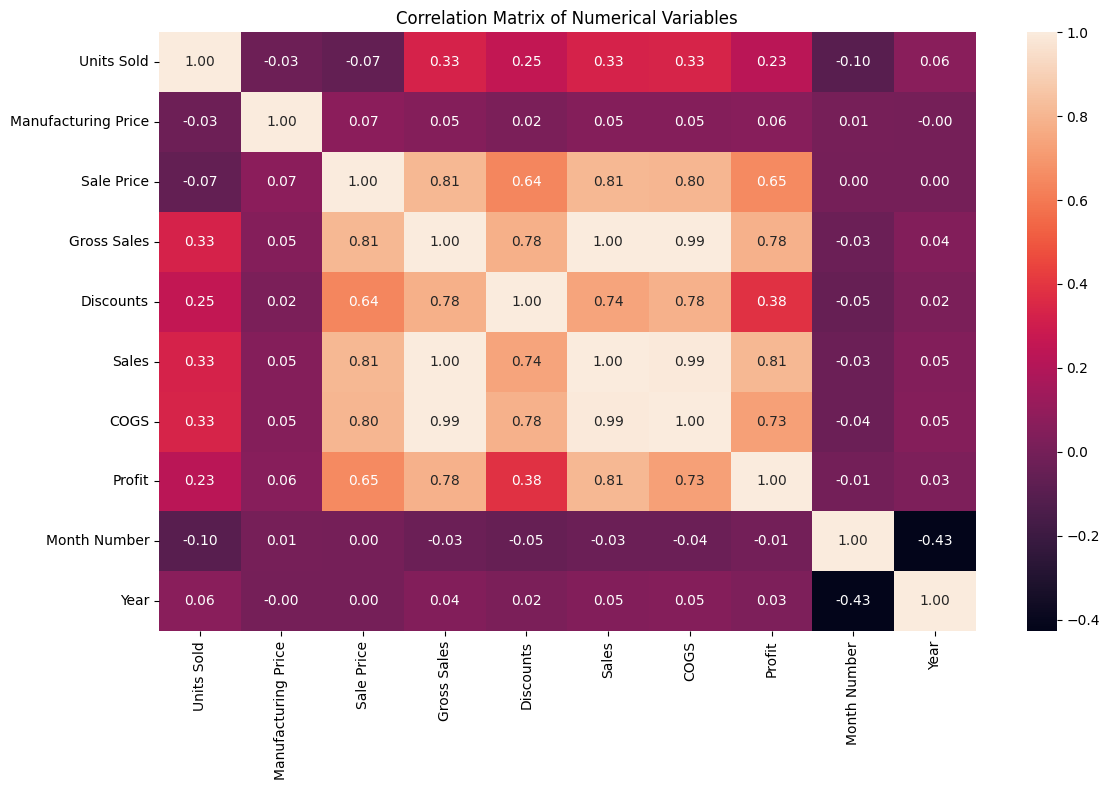

In [38]:
# 1. Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

20.  Regression Model — Sales Prediction

In [39]:
# 1 Import Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
# 2 Select Features and Target Variable
# Features used to predict Sales
features = [
    "Segment",
    "Country",
    "Product",
    "Discount Band",
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Gross Sales",
    "Discounts",
    "COGS",
    "Month Number",
    "Year"
]

# Target variable
X = df[features]
y = df["Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (700, 12)
Target shape: (700,)


In [41]:
# 3 Identify Categorical and Numerical Features
categorical_features = [
    "Segment",
    "Country",
    "Product",
    "Discount Band"
]

numerical_features = [
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Gross Sales",
    "Discounts",
    "COGS",
    "Month Number",
    "Year"
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Segment', 'Country', 'Product', 'Discount Band']

Numerical Features:
['Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'COGS', 'Month Number', 'Year']


In [42]:
# 4 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (560, 12)
Testing data: (140, 12)


In [43]:
# 5 Feature Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [44]:
# 6 Build Linear Regression Model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Segment', 'Country',
                                                   'Product',
                                                   'Discount Band'])])),
                ('regressor', LinearRegression())])

In [45]:
# 7 Train the Regression Model
# Train the model
model.fit(X_train, y_train)

print("Regression model trained successfully.")

Regression model trained successfully.


In [46]:
# 8 Generate Sales Predictions
# Predict Sales for the test dataset
y_pred = model.predict(X_test)

# Display first 10 predictions
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,12066.600,12066.600
1,230310.000,230310.000
2,40769.250,40769.250
3,27968.000,27968.000
4,23436.000,23436.000
5,31133.025,31133.025
6,15474.550,15474.550
7,18035.920,18035.920
8,32670.000,32670.000
9,334302.500,334302.500


21. Model Evaluation

In [47]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Metrics
------------------------
Mean Absolute Error (MAE): 5.235311359034052e-10
Mean Squared Error (MSE): 4.760346197590459e-19
Root Mean Squared Error (RMSE): 6.899526213871833e-10
R² Score: 1.0


22. Actual vs Predicted Sales

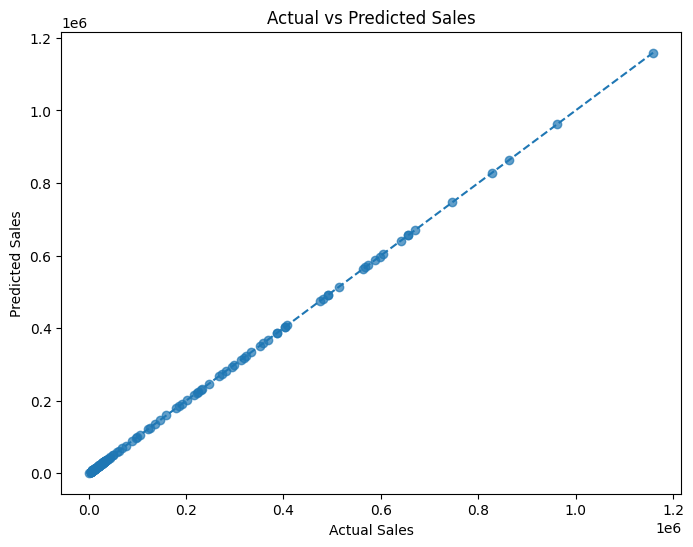

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

23. Model Performance Summary

In [49]:
print("Regression Model Performance")
print("============================")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

if r2 >= 0.8:
    print("\nThe model explains a high proportion of the variation in Sales.")
elif r2 >= 0.5:
    print("\nThe model explains a moderate proportion of the variation in Sales.")
else:
    print("\nThe model explains a lower proportion of the variation in Sales.")

Regression Model Performance
MAE  : 0.00
MSE  : 0.00
RMSE : 0.00
R²   : 1.0000

The model explains a high proportion of the variation in Sales.


24. Power BI & Business Summary Preparation

In [50]:
# 1 Key Performance Indicators (KPIs)
# Create key business metrics
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Units Sold",
        "Average Sales",
        "Average Profit",
        "Total Discounts",
        "Total COGS"
    ],
    "Value": [
        df["Sales"].sum(),
        df["Profit"].sum(),
        df["Units Sold"].sum(),
        df["Sales"].mean(),
        df["Profit"].mean(),
        df["Discounts"].sum(),
        df["COGS"].sum()
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,1.187264e+08
1,Total Profit,1.689370e+07
2,Total Units Sold,1.125806e+06
3,Average Sales,1.696091e+05
4,Average Profit,2.413386e+04
5,Total Discounts,9.205248e+06
6,Total COGS,1.018326e+08


In [51]:
# 2 Country Performance Summary
country_summary = (
    df.groupby("Country")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum"),
        Total_Discounts=("Discounts", "sum")
    )
    .reset_index()
)

country_summary

,Country,Total_Sales,Total_Profit,Units_Sold,Total_Discounts
0,Canada,2.488765e+07,3529228.885,247428.5,2044508.615
1,France,2.435417e+07,3781020.780,240931.0,1727502.220
2,Germany,2.350534e+07,3680388.820,201494.0,1416126.680
3,Mexico,2.094935e+07,2907523.110,203325.0,1777582.890
4,United States of America,2.502983e+07,2995540.665,232627.5,2239527.835


In [52]:
# 3 Product Performance Summary
product_summary = (
    df.groupby("Product")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum"),
        Total_Discounts=("Discounts", "sum")
    )
    .reset_index()
)

product_summary

,Product,Total_Sales,Total_Profit,Units_Sold,Total_Discounts
0,Amarilla,1.774712e+07,2814104.060,155315.0,1290163.440
1,Carretera,1.381531e+07,1826804.885,146846.0,1122212.615
2,Montana,1.539080e+07,2114754.880,154198.0,1159032.620
3,Paseo,3.301114e+07,4797437.950,338239.5,2600518.050
4,VTT,2.051192e+07,3034608.020,168783.0,1456612.480
5,Velo,1.825006e+07,2305992.465,162424.5,1576709.035


In [53]:
# 4 Segment Performance Summary
segment_summary = (
    df.groupby("Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum"),
        Total_Discounts=("Discounts", "sum")
    )
    .reset_index()
)

segment_summary

,Segment,Total_Sales,Total_Profit,Units_Sold,Total_Discounts
0,Channel Partners,1.800594e+06,1.316803e+06,161263.5,134568.360
1,Enterprise,1.961169e+07,-6.145456e+05,168552.0,1457305.625
2,Government,5.250426e+07,1.138817e+07,470673.5,3898805.830
3,Midmarket,2.381883e+06,6.601031e+05,172178.0,200786.925
4,Small Business,4.242792e+07,4.143168e+06,153139.0,3513781.500


In [54]:
# 5 Yearly Sales and Profit Summary
year_summary = (
    df.groupby("Year")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

year_summary

,Year,Total_Sales,Total_Profit,Units_Sold
0,2013,26415255.51,3878464.51,264674.0
1,2014,92311094.75,13015237.75,861132.0


In [55]:
# 6 Monthly Sales Summary
monthly_summary = (
    df.groupby(["Year", "Month Number", "Month Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values(["Year", "Month Number"])
)

monthly_summary

,Year,Month Number,Month Name,Total_Sales,Total_Profit
0,2013,9,September,4484000.03,763603.03
1,2013,10,October,9295611.10,1657795.10
2,2013,11,November,7267203.30,765502.30
3,2013,12,December,5368441.08,691564.08
4,2014,1,January,6607761.68,814028.68
5,2014,2,February,7297531.39,1148547.39
6,2014,3,March,5586859.87,669866.87
7,2014,4,April,6964775.07,929984.57
8,2014,5,May,6210211.06,828640.06
9,2014,6,June,9518893.82,1473753.82


In [56]:
# 7 Export Analysis Results to Excel
# Create Excel workbook containing the main analysis tables
excel_path = "../excel/sales_analysis.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    kpi_summary.to_excel(writer, sheet_name="KPIs", index=False)
    country_summary.to_excel(writer, sheet_name="Country Analysis", index=False)
    product_summary.to_excel(writer, sheet_name="Product Analysis", index=False)
    segment_summary.to_excel(writer, sheet_name="Segment Analysis", index=False)
    year_summary.to_excel(writer, sheet_name="Year Analysis", index=False)
    monthly_summary.to_excel(writer, sheet_name="Monthly Analysis", index=False)

print("Excel analysis file created successfully!")
print("File:", excel_path)

Excel analysis file created successfully!
File: ../excel/sales_analysis.xlsx


25. SQL Analysis

In [57]:
sql_queries = """
-- 1. Total Sales, Profit and Units Sold
SELECT
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(`Units Sold`) AS Total_Units_Sold
FROM sales_data_cleaned;


-- 2. Sales by Country
SELECT
    Country,
    SUM(Sales) AS Total_Sales
FROM sales_data_cleaned
GROUP BY Country
ORDER BY Total_Sales DESC;


-- 3. Profit by Product
SELECT
    Product,
    SUM(Profit) AS Total_Profit
FROM sales_data_cleaned
GROUP BY Product
ORDER BY Total_Profit DESC;


-- 4. Sales by Segment
SELECT
    Segment,
    SUM(Sales) AS Total_Sales
FROM sales_data_cleaned
GROUP BY Segment
ORDER BY Total_Sales DESC;


-- 5. Yearly Sales and Profit
SELECT
    Year,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales_data_cleaned
GROUP BY Year
ORDER BY Year;


-- 6. Monthly Sales
SELECT
    Year,
    `Month Number`,
    `Month Name`,
    SUM(Sales) AS Total_Sales
FROM sales_data_cleaned
GROUP BY Year, `Month Number`, `Month Name`
ORDER BY Year, `Month Number`;


-- 7. Discount Band Analysis
SELECT
    `Discount Band`,
    SUM(Sales) AS Total_Sales,
    SUM(Discounts) AS Total_Discounts,
    SUM(Profit) AS Total_Profit
FROM sales_data_cleaned
GROUP BY `Discount Band`
ORDER BY Total_Sales DESC;


-- 8. Sales and Profit by Country
SELECT
    Country,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(`Units Sold`) AS Total_Units_Sold
FROM sales_data_cleaned
GROUP BY Country
ORDER BY Total_Sales DESC;


-- 9. Top 10 Sales Transactions
SELECT
    Country,
    Product,
    Segment,
    Sales,
    Profit,
    `Units Sold`
FROM sales_data_cleaned
ORDER BY Sales DESC
LIMIT 10;


-- 10. Transactions with Negative Profit
SELECT
    Country,
    Product,
    Segment,
    Sales,
    Profit
FROM sales_data_cleaned
WHERE Profit < 0
ORDER BY Profit ASC;
"""

with open("../sql/analysis_queries.sql", "w", encoding="utf-8") as file:
    file.write(sql_queries)

print("SQL analysis file created successfully!")
print("File: ../sql/analysis_queries.sql")

SQL analysis file created successfully!
File: ../sql/analysis_queries.sql


26. Regression Model Results

In [58]:
regression_results = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

regression_results

,Metric,Value
0,Mean Absolute Error (MAE),5.235311e-10
1,Mean Squared Error (MSE),4.760346e-19
2,Root Mean Squared Error (RMSE),6.899526e-10
3,R² Score,1.000000e+00


In [59]:
regression_path = "../excel/regression_results.xlsx"

with pd.ExcelWriter(regression_path, engine="openpyxl") as writer:
    regression_results.to_excel(
        writer,
        sheet_name="Model Metrics",
        index=False
    )
    
    comparison.to_excel(
        writer,
        sheet_name="Actual vs Predicted",
        index=False
    )

print("Regression results exported successfully!")
print("File:", regression_path)

Regression results exported successfully!
File: ../excel/regression_results.xlsx


27. Save Important Visualizations

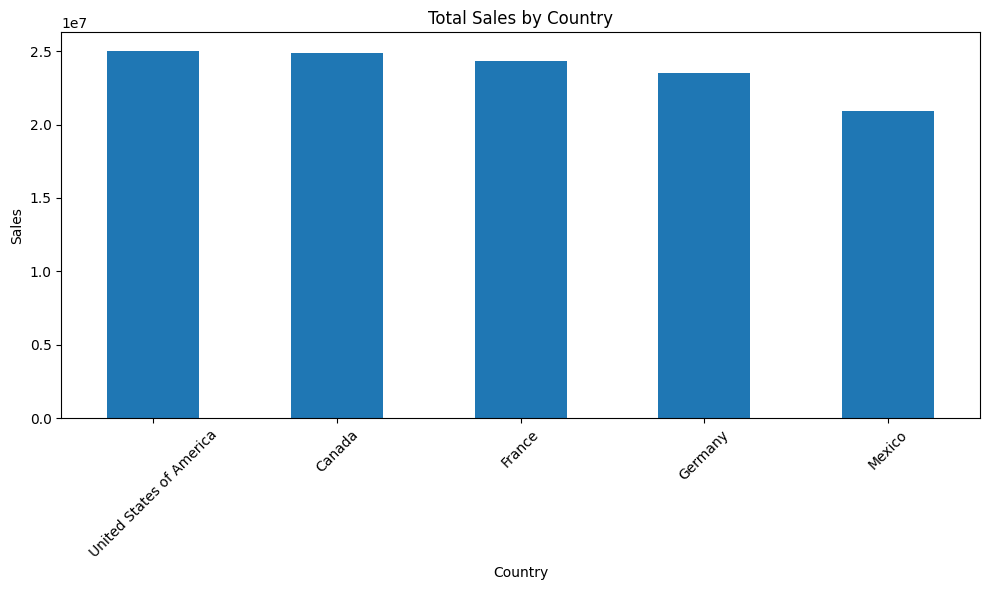

In [60]:
import os

os.makedirs("../screenshots", exist_ok=True)

# Sales by Country
plt.figure(figsize=(10, 6))
sales_by_country.plot(kind="bar")
plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/sales_by_country.png", dpi=300)
plt.show()

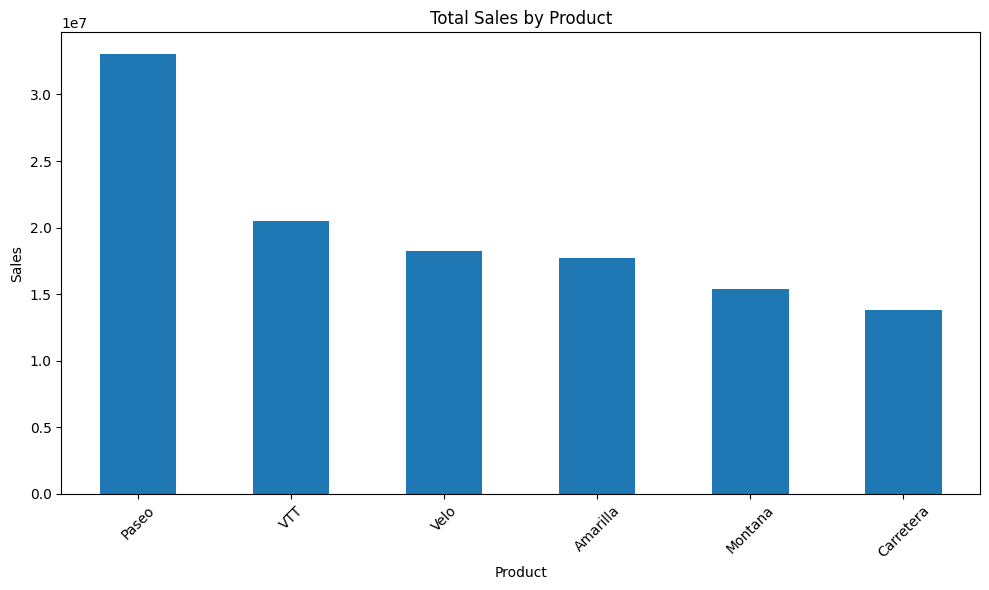

In [61]:
# Sales by Product
plt.figure(figsize=(10, 6))
sales_by_product.plot(kind="bar")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/sales_by_product.png", dpi=300)
plt.show()

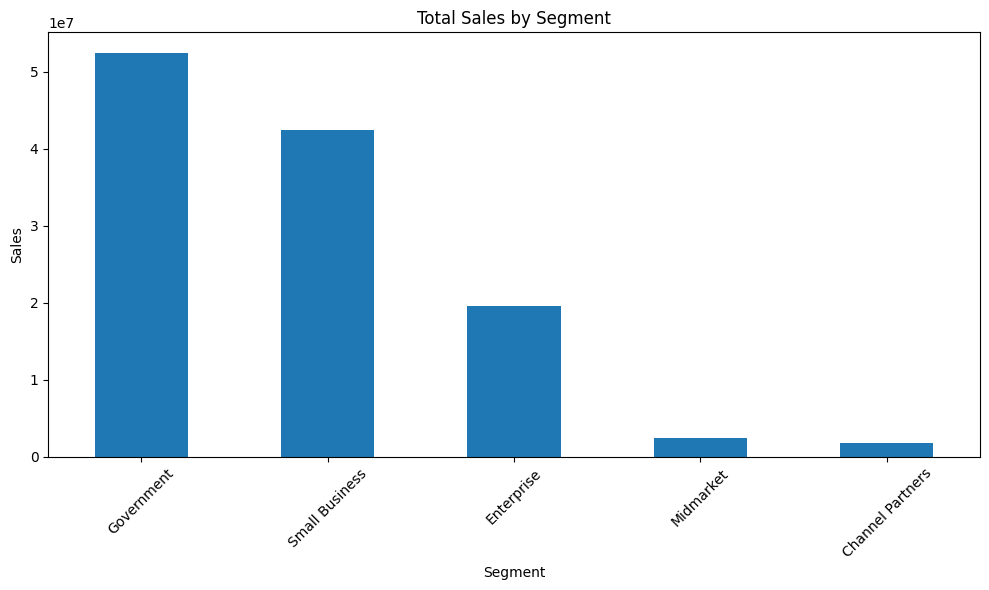

In [62]:
# Sales by Segment
plt.figure(figsize=(10, 6))
sales_by_segment.plot(kind="bar")
plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/sales_by_segment.png", dpi=300)
plt.show()

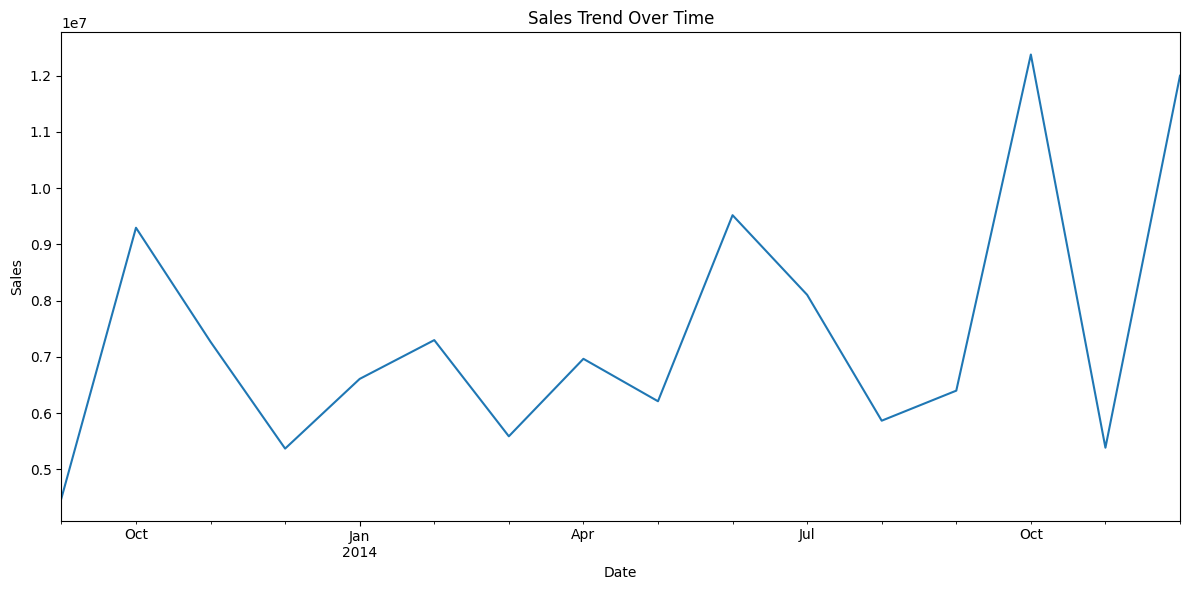

In [63]:
# Sales Trend
plt.figure(figsize=(12, 6))
sales_by_date.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("../screenshots/sales_trend.png", dpi=300)
plt.show()

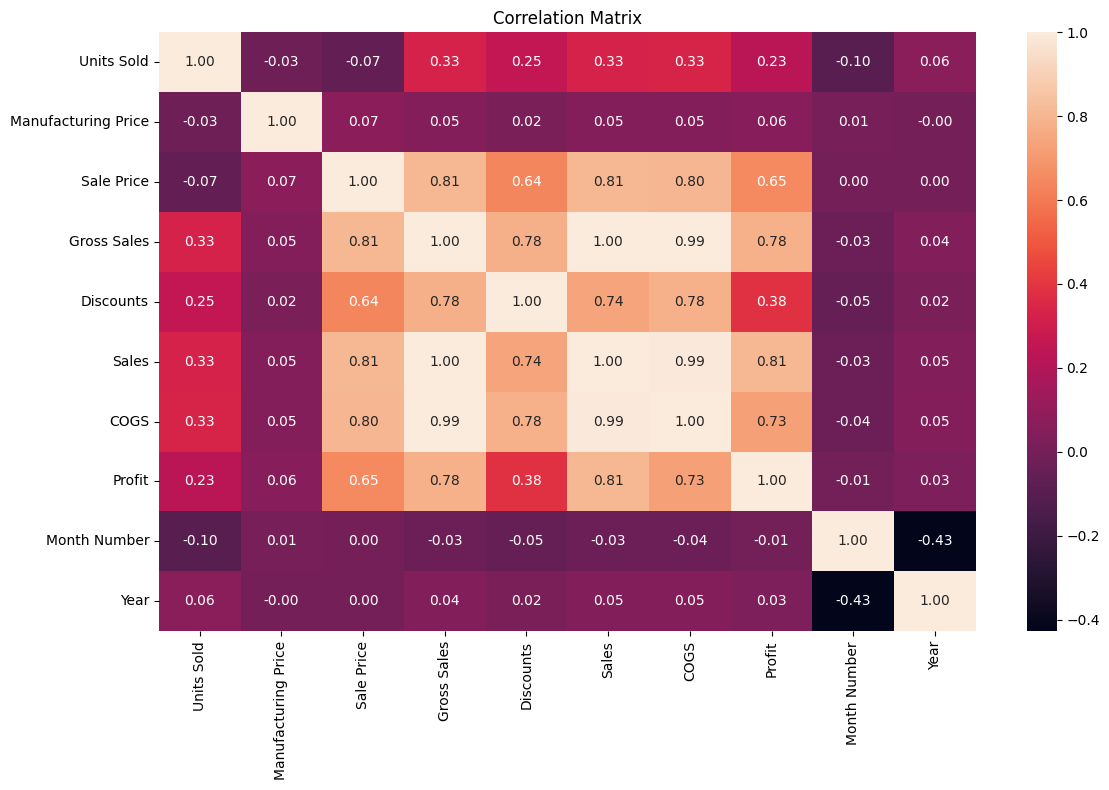

In [64]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../screenshots/correlation_heatmap.png", dpi=300)
plt.show()

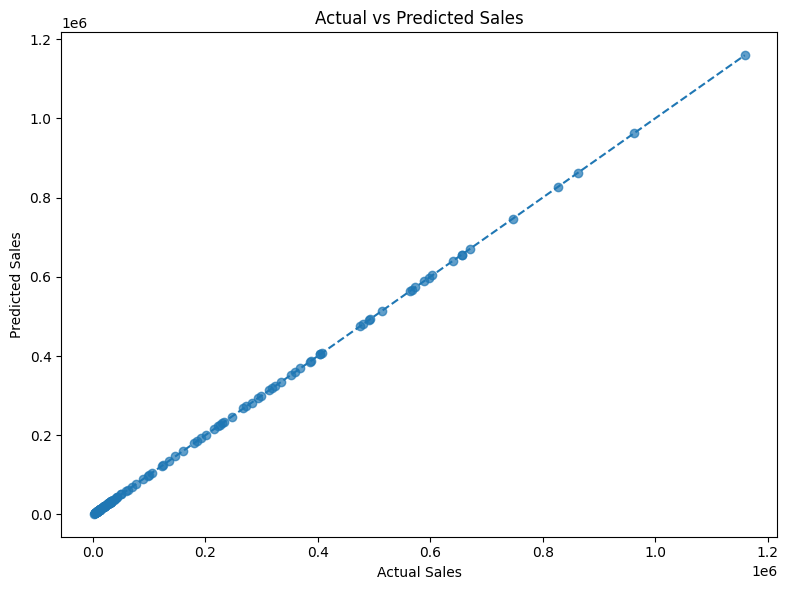

Important charts saved successfully!


In [65]:
# Actual vs Predicted Sales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.savefig("../screenshots/actual_vs_predicted.png", dpi=300)
plt.show()

print("Important charts saved successfully!")

28. Power BI Dashboard Preparation

In [66]:
# Create a Power BI-ready dataset
powerbi_path = "../powerbi/sales_powerbi_data.csv"

df.to_csv(powerbi_path, index=False)

print("Power BI dataset created successfully!")
print("File:", powerbi_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Power BI dataset created successfully!
File: ../powerbi/sales_powerbi_data.csv
Rows: 700
Columns: 16


29. Findings and Business Recommendations

In [67]:
top_country = sales_by_country.idxmax()
top_country_sales = sales_by_country.max()

top_product = sales_by_product.idxmax()
top_product_sales = sales_by_product.max()

top_segment = sales_by_segment.idxmax()
top_segment_sales = sales_by_segment.max()

top_profit_product = (
    df.groupby("Product")["Profit"]
    .sum()
    .idxmax()
)

top_profit_product_value = (
    df.groupby("Product")["Profit"]
    .sum()
    .max()
)

print("Key Findings")
print("------------")
print(f"Highest Sales Country: {top_country}")
print(f"Sales: {top_country_sales:.2f}")
print()
print(f"Highest Sales Product: {top_product}")
print(f"Sales: {top_product_sales:.2f}")
print()
print(f"Highest Sales Segment: {top_segment}")
print(f"Sales: {top_segment_sales:.2f}")
print()
print(f"Highest Profit Product: {top_profit_product}")
print(f"Profit: {top_profit_product_value:.2f}")

Key Findings
------------
Highest Sales Country: United States of America
Sales: 25029830.16

Highest Sales Product: Paseo
Sales: 33011143.95

Highest Sales Segment: Government
Sales: 52504260.67

Highest Profit Product: Paseo
Profit: 4797437.95


In [68]:
print("Capstone project analysis completed successfully!")
print()
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print()
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Units Sold:", df["Units Sold"].sum())
print()
print("Regression R² Score:", r2)

Capstone project analysis completed successfully!

Final Dataset Shape: (700, 16)
Missing Values: 0
Duplicate Rows: 0

Total Sales: 118726350.25999999
Total Profit: 16893702.26
Total Units Sold: 1125806.0

Regression R² Score: 1.0
